In [9]:
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture


In [16]:

image_path = 'path_to_your_image.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [12]:
#Kmeans
pixels = image_rgb.reshape((-1, 3))
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pixels)
kmeans_mask = kmeans_labels.reshape(image_rgb.shape[:2])

In [13]:
#Gaussian
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(pixels)
gmm_mask = gmm_labels.reshape(image_rgb.shape[:2])

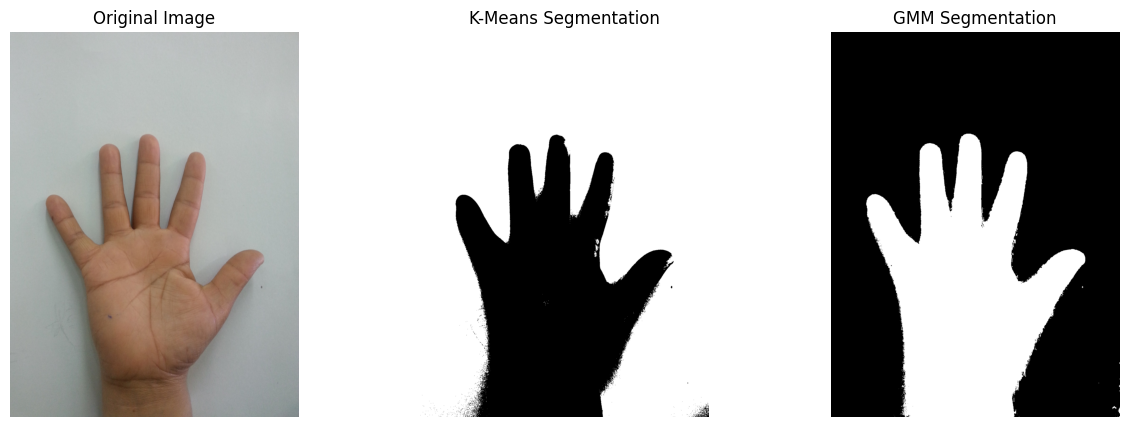

In [14]:
# Plot the original image and masks
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(kmeans_mask, cmap="gray")
axes[1].set_title("K-Means Segmentation")
axes[1].axis("off")

axes[2].imshow(gmm_mask, cmap="gray")
axes[2].set_title("GMM Segmentation")
axes[2].axis("off")

plt.show()